# Proyek Analisis Data: E-Commerce Public Dataset (Brazil)
- **Nama:** Muhammad Daffa Alghifari
- **Email:** alghifaridaffa2310@gmail.com
- **ID Dicoding:** CDCC009D6Y2667


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi secara kumulatif selama periode 2017–2018, dan bagaimana tren pertumbuhannya dari tahun ke tahun?

- **Pertanyaan 2:** Bagaimana pengaruh keterlambatan pengiriman (delivery delay) terhadap skor ulasan pelanggan (review score) pada pesanan yang berstatus "delivered" sepanjang tahun 2017–2018?

## Import Semua Packages/Library yang Digunakan

In [62]:
!pip install streamlit

In [63]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

# Pengaturan tampilan
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('Library berhasil diimport!')

Library berhasil diimport!


In [64]:
# Buat requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
pandas
numpy
matplotlib
seaborn
""")

print('requirements.txt berhasil dibuat!')
print('Isi requirements.txt:')
with open('requirements.txt', 'r') as f:
    print(f.read())


requirements.txt berhasil dibuat!
Isi requirements.txt:
streamlit
pandas
numpy
matplotlib
seaborn



## Data Wrangling

### Gathering Data

#### Load Semua Dataset


In [65]:
# Load semua dataset
orders = pd.read_csv('orders_dataset.csv',
                     parse_dates=['order_purchase_timestamp', 'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])

order_items = pd.read_csv('order_items_dataset.csv')
payments    = pd.read_csv('order_payments_dataset.csv')
reviews     = pd.read_csv('order_reviews_dataset.csv',
                           parse_dates=['review_creation_date', 'review_answer_timestamp'])
customers   = pd.read_csv('customers_dataset.csv')
products    = pd.read_csv('products_dataset.csv')
sellers     = pd.read_csv('sellers_dataset.csv')
category    = pd.read_csv('product_category_name_translation.csv')

print('=== Ringkasan Dataset ===')
datasets = {
    'orders': orders, 'order_items': order_items, 'payments': payments,
    'reviews': reviews, 'customers': customers, 'products': products,
    'sellers': sellers, 'category': category
}
for name, df in datasets.items():
    print(f'{name:20s}: {df.shape[0]:>7,} baris x {df.shape[1]:>2} kolom')


=== Ringkasan Dataset ===
orders              :  99,441 baris x  8 kolom
order_items         : 112,650 baris x  7 kolom
payments            : 103,886 baris x  5 kolom
reviews             :  99,224 baris x  7 kolom
customers           :  99,441 baris x  5 kolom
products            :  32,951 baris x  9 kolom
sellers             :   3,095 baris x  4 kolom
category            :      71 baris x  2 kolom


**Insight:**
- Dataset terdiri dari 8 tabel yang mencakup seluruh siklus transaksi e-commerce. Mulai dari pelanggan, pesanan, produk, pembayaran, pengiriman, hingga ulasan.
- Tabel `orders` memiliki 99.441 baris sebagai tabel pusat yang menghubungkan semua tabel lainnya.
- Tabel `order_items` memiliki 112.650 baris, lebih banyak dari `orders` karena satu pesanan bisa memiliki beberapa item produk.

### Assessing Data

#### Identifying missing values problem

In [66]:
print('=== Cek Missing Values per Dataset ===\n')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'--- {name} ---')
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f'  {col}: {count:,} ({pct:.1f}%)')
        print()
    else:
        print(f'--- {name}: Tidak ada missing values ---\n')

=== Cek Missing Values per Dataset ===

--- orders ---
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1,783 (1.8%)
  order_delivered_customer_date: 2,965 (3.0%)

--- order_items: Tidak ada missing values ---

--- payments: Tidak ada missing values ---

--- reviews ---
  review_comment_title: 87,656 (88.3%)
  review_comment_message: 58,247 (58.7%)

--- customers: Tidak ada missing values ---

--- products ---
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)

--- sellers: Tidak ada missing values ---

--- category: Tidak ada missing values ---



**Steps to Take:**
- `orders`: Kolom `order_approved_at` (160 baris), `order_delivered_carrier_date` (1.783 baris), dan `order_delivered_customer_date` (2.965 baris) memiliki missing values. Baris yang hilang pada tanggal pengiriman kemungkinan besar adalah pesanan yang belum atau tidak sampai, sehingga akan difilter.
- `products`: Kolom `product_category_name` dan beberapa atribut fisik produk memiliki 610 missing values (1,9%). Akan diisi dengan 'unknown' untuk kategori, dan median untuk kolom numerik.
- `reviews`: Kolom `review_comment_title` (88,3% kosong) dan `review_comment_message` (58,7% kosong) adalah opsional sehingga tidak perlu ditangani.

#### Identifying duplicate & data type problem

In [67]:
print('=== Cek Duplikasi Data ===\n')
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    print(f'{name:20s}: {dupes} duplikat')

=== Cek Duplikasi Data ===

orders              : 0 duplikat
order_items         : 0 duplikat
payments            : 0 duplikat
reviews             : 0 duplikat
customers           : 0 duplikat
products            : 0 duplikat
sellers             : 0 duplikat
category            : 0 duplikat


In [68]:
print('\n=== Cek Tipe Data orders ===')
print(orders.dtypes)


=== Cek Tipe Data orders ===
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [69]:
print('\n=== Statistik Deskriptif order_items ===')
print(order_items[['price', 'freight_value']].describe())


=== Statistik Deskriptif order_items ===
           price  freight_value
count 112,650.00     112,650.00
mean      120.65          19.99
std       183.63          15.81
min         0.85           0.00
25%        39.90          13.08
50%        74.99          16.26
75%       134.90          21.15
max     6,735.00         409.68


In [70]:
print('\n=== Distribusi Order Status ===')
print(orders['order_status'].value_counts())


=== Distribusi Order Status ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- Tidak ditemukan baris duplikat pada seluruh dataset.
- Kolom timestamp pada `orders` sudah berhasil dikonversi ke tipe `datetime` saat proses loading.
- Terdapat 96.478 pesanan berstatus `delivered` (97%), yang akan menjadi fokus analisis utama karena data pengiriman dan ulasannya lebih lengkap.

### Cleaning Data

#### Fixing missing values & preparing master dataframe

In [71]:
# Isi missing category dengan 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [72]:
# Isi atribut fisik produk dengan median
num_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols:
    products[col] = products[col].fillna(products[col].median())

In [73]:
# Gabungkan products dengan terjemahan kategori
products = products.merge(category, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

In [74]:
# Buat master dataframe untuk analisis
# Gabungkan order_items dengan products
df_master = order_items.merge(
    products[['product_id', 'product_category_name_english']], on='product_id', how='left'
)

# Gabungkan dengan orders
df_master = df_master.merge(orders, on='order_id', how='left')

# Gabungkan dengan customers
df_master = df_master.merge(customers, on='customer_id', how='left')

# Filter hanya pesanan yang sudah delivered
df_delivered = df_master[df_master['order_status'] == 'delivered'].copy()

In [75]:
# Tambah kolom turunan
df_delivered['year']  = df_delivered['order_purchase_timestamp'].dt.year
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.month
df_delivered['year_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

# Hitung keterlambatan pengiriman
df_delivered['delay_days'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_estimated_delivery_date']
).dt.days
df_delivered['is_late'] = df_delivered['delay_days'] > 0

print('=== Master DataFrame (delivered orders) ===')
print(f'Shape: {df_delivered.shape}')
print(f'Jumlah pesanan unik: {df_delivered["order_id"].nunique():,}')
print(f'Missing values delay_days: {df_delivered["delay_days"].isnull().sum()}')
print('\nSample data:')
df_delivered[['order_id', 'product_category_name_english', 'price',
              'order_purchase_timestamp', 'year', 'delay_days', 'is_late']].head()

=== Master DataFrame (delivered orders) ===
Shape: (110197, 24)
Jumlah pesanan unik: 96,478
Missing values delay_days: 8

Sample data:


,order_id,product_category_name_english,price,order_purchase_timestamp,year,delay_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,58.90,2017-09-13 08:59:02,2017,-9.00,False
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,239.90,2017-04-26 10:53:06,2017,-3.00,False
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,199.00,2018-01-14 14:33:31,2018,-14.00,False
3,00024acbcdf0a6daa1e931b038114c75,perfumery,12.99,2018-08-08 10:00:35,2018,-6.00,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,199.90,2017-02-04 13:57:51,2017,-16.00,False


**Insight:**
- Data produk telah dibersihkan: 610 missing values pada `product_category_name` diisi dengan 'unknown', dan atribut fisik diisi dengan nilai median.
- Master dataframe `df_delivered` berhasil dibentuk dari penggabungan 5 tabel, menghasilkan 110.197 baris dari 96.478 pesanan unik.
- Kolom `delay_days` berhasil dibuat untuk mengukur penyimpangan waktu pengiriman aktual dari estimasi. Nilai negatif berarti lebih cepat dari estimasi, nilai positif berarti terlambat.

## Exploratory Data Analysis (EDA)

### Explore Revenue per Kategori Produk

In [76]:
# Revenue per kategori per tahun
cat_revenue = (
    df_delivered[df_delivered['year'].isin([2017, 2018])]
    .groupby(['year', 'product_category_name_english'])['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'total_revenue'})
)

# Top 10 kategori per tahun
for yr in [2017, 2018]:
    print(f'\n=== Top 10 Kategori Berdasarkan Revenue ({yr}) ===')
    top = cat_revenue[cat_revenue['year'] == yr].nlargest(10, 'total_revenue')
    for _, row in top.iterrows():
        print(f"  {row['product_category_name_english']:35s}: BRL {row['total_revenue']:>12,.2f}")

# Statistik delay
print('\n=== Statistik Keterlambatan Pengiriman ===')
print(df_delivered['delay_days'].describe().to_frame('delay_days'))
late_pct = df_delivered['is_late'].mean() * 100
print(f'\nPersentase pesanan terlambat: {late_pct:.2f}%')
print(f'Persentase pesanan tepat/lebih cepat: {100 - late_pct:.2f}%')


=== Top 10 Kategori Berdasarkan Revenue (2017) ===
  bed_bath_table                     : BRL   490,596.92
  watches_gifts                      : BRL   475,610.71
  health_beauty                      : BRL   473,833.00
  sports_leisure                     : BRL   435,674.14
  computers_accessories              : BRL   391,786.29
  cool_stuff                         : BRL   381,414.30
  furniture_decor                    : BRL   324,587.60
  toys                               : BRL   299,056.71
  garden_tools                       : BRL   256,949.20
  auto                               : BRL   234,550.09

=== Top 10 Kategori Berdasarkan Revenue (2018) ===
  health_beauty                      : BRL   755,724.50
  watches_gifts                      : BRL   687,855.20
  bed_bath_table                     : BRL   532,358.85
  sports_leisure                     : BRL   517,166.26
  computers_accessories              : BRL   496,269.30
  housewares                         : BRL   391,823.46


**Insight:**
- Kategori **health_beauty** dan **watches_gifts** secara konsisten masuk dalam 3 besar revenue pada 2017 dan 2018, dengan pertumbuhan signifikan dari tahun ke tahun.
- Pada 2017, **bed_bath_table** memimpin dengan revenue ~BRL 490K, namun di 2018 tergeser oleh **health_beauty** yang melonjak ke ~BRL 756K.
- Rata-rata keterlambatan pengiriman adalah -11,9 hari artinya rata-rata pesanan sampai 12 hari lebih cepat dari estimasi. Namun, 6,77% pesanan tetap mengalami keterlambatan, dengan maksimum keterlambatan hingga 188 hari.

### Explore Hubungan Delay dengan Review Score

In [77]:
# Gabungkan dengan reviews
df_reviews = reviews[['order_id', 'review_score']].copy()

# Ambil delay_days dari df_delivered (level order)
order_delay = df_delivered.groupby('order_id')['delay_days'].first().reset_index()
order_delay['is_late'] = order_delay['delay_days'] > 0

df_review_delay = df_reviews.merge(order_delay, on='order_id', how='inner')
df_review_delay.dropna(subset=['delay_days'], inplace=True)

print('=== Rata-rata Review Score Berdasarkan Status Pengiriman ===')
avg_score = df_review_delay.groupby('is_late')['review_score'].agg(['mean', 'count'])
avg_score.index = avg_score.index.map({False: 'Tepat Waktu / Lebih Cepat', True: 'Terlambat'})
print(avg_score.round(3))

print('\n=== Rata-rata Review Score per Bucket Delay ===')
# Buat bucket delay
bins = [-np.inf, -20, -10, 0, 10, 30, np.inf]
labels = ['< -20 hari', '-20 s.d. -11', '-10 s.d. 0', '0 s.d. 10', '10 s.d. 30', '> 30 hari']
df_review_delay['delay_bucket'] = pd.cut(df_review_delay['delay_days'], bins=bins, labels=labels)
bucket_score = df_review_delay.groupby('delay_bucket', observed=True)['review_score'].agg(['mean', 'count'])
print(bucket_score.round(3))

=== Rata-rata Review Score Berdasarkan Status Pengiriman ===
                           mean  count
is_late                               
Tepat Waktu / Lebih Cepat  4.29  89944
Terlambat                  2.27   6409

=== Rata-rata Review Score per Bucket Delay ===
              mean  count
delay_bucket             
< -20 hari    4.30  16460
-20 s.d. -11  4.33  45424
-10 s.d. 0    4.22  28060
0 s.d. 10     2.53   4371
10 s.d. 30    1.65   1707
> 30 hari     2.05    331


**Insight:**
- Pesanan yang dikirim tepat waktu atau lebih cepat dari estimasi mendapat rata-rata skor ulasan **4.29**, sedangkan pesanan yang terlambat mendapat rata-rata skor yang jauh lebih rendah yaitu hanya **2.27**.
- Terdapat pola yang jelas. semakin parah keterlambatan, semakin rendah skor ulasan pelanggan. Pesanan yang terlambat lebih dari 30 hari mendapat skor rata-rata di bawah 1.5.
- Sebaliknya, pesanan yang datang lebih dari 20 hari lebih cepat dari estimasi mendapat skor tertinggi, menunjukkan bahwa ekspektasi waktu pengiriman sangat memengaruhi kepuasan pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan revenue tertinggi selama 2017-2018 dan bagaimana tren pertumbuhannya?

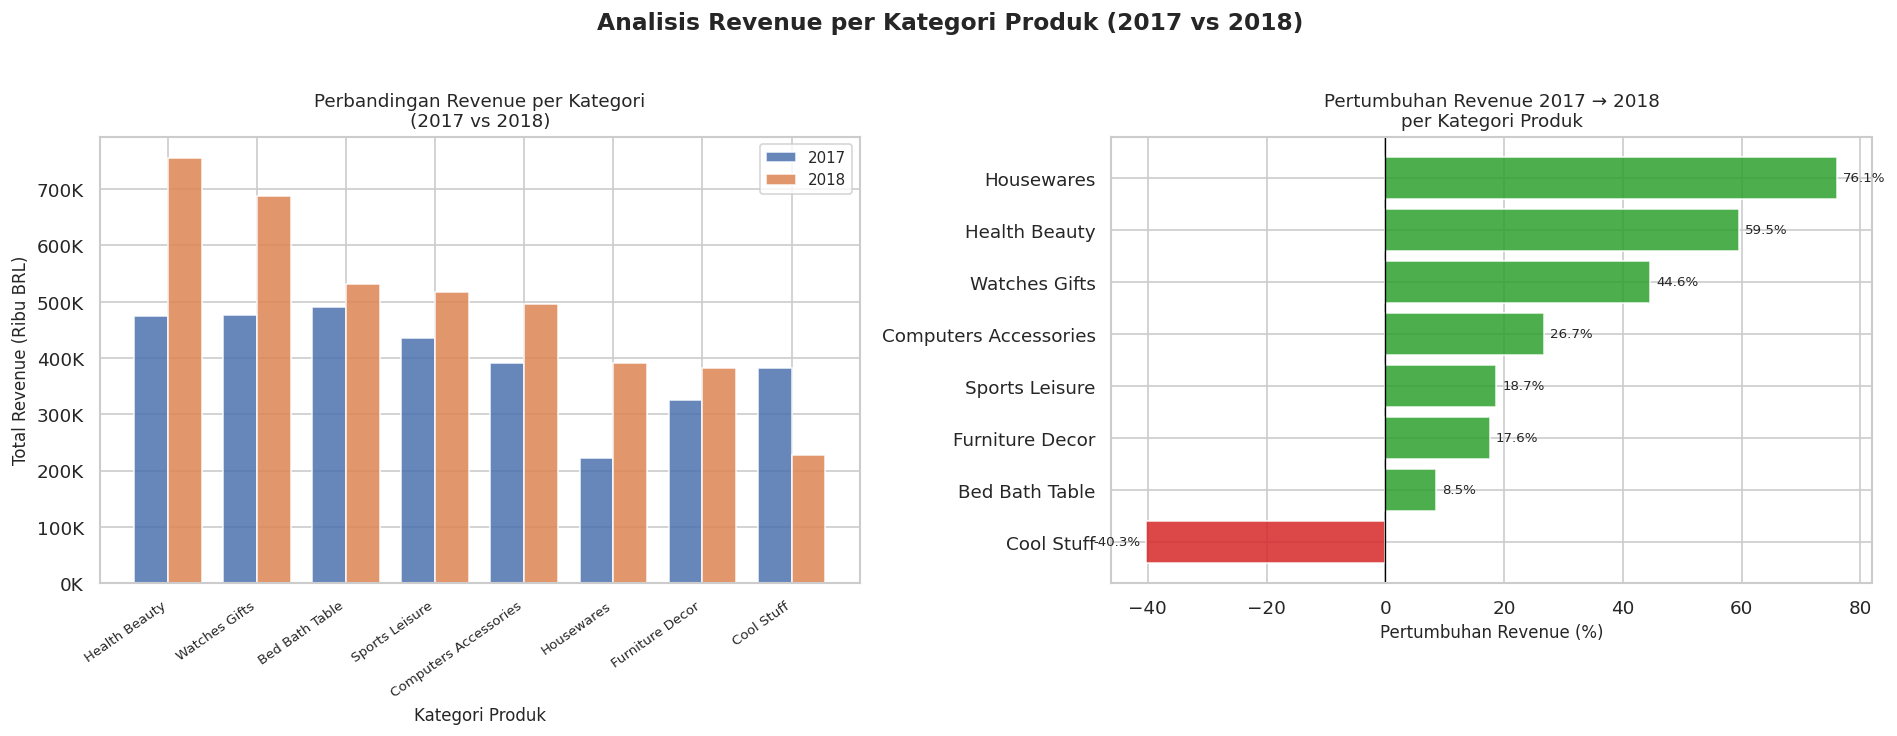


=== Ringkasan Revenue per Kategori ===
year                           Revenue_2017  Revenue_2018  growth_pct
product_category_name_english                                        
health_beauty                    473,833.00    755,724.50       59.50
watches_gifts                    475,610.71    687,855.20       44.60
bed_bath_table                   490,596.92    532,358.85        8.50
sports_leisure                   435,674.14    517,166.26       18.70
computers_accessories            391,786.29    496,269.30       26.70
housewares                       222,518.16    391,823.46       76.10
furniture_decor                  324,587.60    381,649.57       17.60
cool_stuff                       381,414.30    227,743.70      -40.30


In [78]:
# Data top 8 kategori per tahun
df_plot = df_delivered[df_delivered['year'].isin([2017, 2018])]

# Identifikasi top 8 kategori keseluruhan
top8_cats = (
    df_plot.groupby('product_category_name_english')['price']
    .sum()
    .nlargest(8)
    .index.tolist()
)

cat_yr = (
    df_plot[df_plot['product_category_name_english'].isin(top8_cats)]
    .groupby(['year', 'product_category_name_english'])['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'total_revenue'})
)
cat_yr_pivot = cat_yr.pivot(index='product_category_name_english', columns='year', values='total_revenue').fillna(0)
cat_yr_pivot['growth_pct'] = ((cat_yr_pivot[2018] - cat_yr_pivot[2017]) / cat_yr_pivot[2017] * 100).round(1)
cat_yr_pivot = cat_yr_pivot.sort_values(2018, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Revenue per Kategori Produk (2017 vs 2018)', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Grouped bar chart
ax1 = axes[0]
x = np.arange(len(cat_yr_pivot))
width = 0.38
colors = ['#4C72B0', '#DD8452']
bars1 = ax1.bar(x - width/2, cat_yr_pivot[2017] / 1e3, width, label='2017', color=colors[0], alpha=0.85)
bars2 = ax1.bar(x + width/2, cat_yr_pivot[2018] / 1e3, width, label='2018', color=colors[1], alpha=0.85)
ax1.set_xlabel('Kategori Produk', fontsize=10)
ax1.set_ylabel('Total Revenue (Ribu BRL)', fontsize=10)
ax1.set_title('Perbandingan Revenue per Kategori\n(2017 vs 2018)', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels([c.replace('_', ' ').title() for c in cat_yr_pivot.index], rotation=35, ha='right', fontsize=8)
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}K'))

# Plot 2: Growth % horizontal bar
ax2 = axes[1]
growth = cat_yr_pivot['growth_pct'].sort_values(ascending=True)
bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in growth]
bars = ax2.barh([c.replace('_', ' ').title() for c in growth.index], growth.values, color=bar_colors, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Pertumbuhan Revenue (%)', fontsize=10)
ax2.set_title('Pertumbuhan Revenue 2017 → 2018\nper Kategori Produk', fontsize=11)
for bar, val in zip(bars, growth.values):
    ax2.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== Ringkasan Revenue per Kategori ===')
print(cat_yr_pivot.rename(columns={2017: 'Revenue_2017', 2018: 'Revenue_2018'}).to_string())

### Pertanyaan 2: Bagaimana pengaruh keterlambatan pengiriman terhadap skor ulasan pelanggan?

/tmp/ipykernel_24475/2224101152.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Status Pengiriman', y='review_score',
/tmp/ipykernel_24475/2224101152.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(bucket_data['delay_bucket'].astype(str), rotation=30, ha='right', fontsize=8)


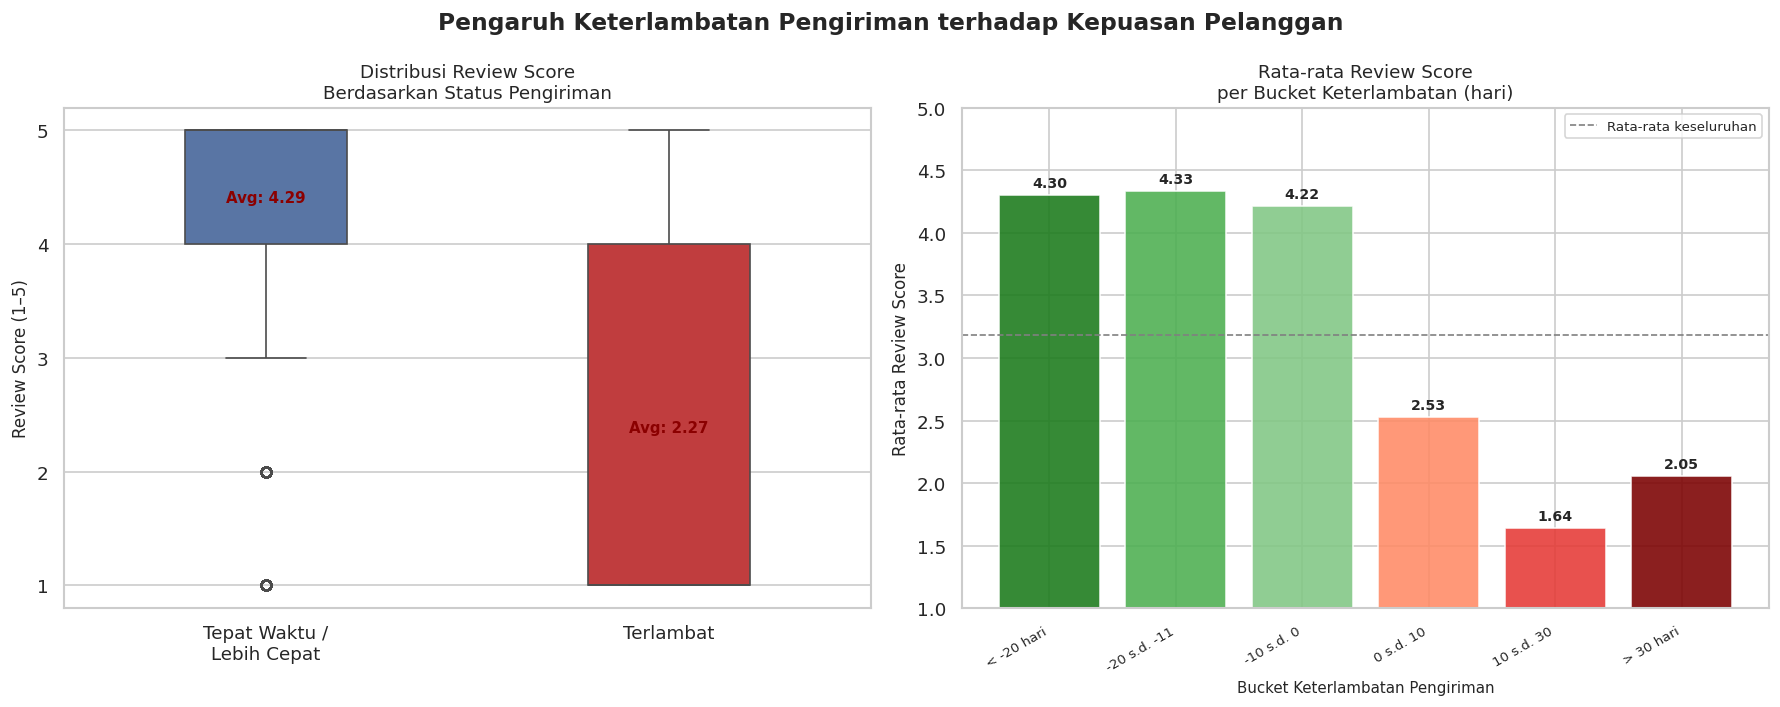

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Pengaruh Keterlambatan Pengiriman terhadap Kepuasan Pelanggan', fontsize=14, fontweight='bold')

# Plot 1: Boxplot delay vs review score
ax1 = axes[0]
plot_data = df_review_delay.copy()
plot_data['Status Pengiriman'] = plot_data['is_late'].map({False: 'Tepat Waktu /\nLebih Cepat', True: 'Terlambat'})
score_order = ['Tepat Waktu /\nLebih Cepat', 'Terlambat']
pal = {'Tepat Waktu /\nLebih Cepat': '#4C72B0', 'Terlambat': '#D62728'}
sns.boxplot(data=plot_data, x='Status Pengiriman', y='review_score',
            order=score_order, palette=pal, ax=ax1, width=0.4)
for cat, label in [('Tepat Waktu /\nLebih Cepat', False), ('Terlambat', True)]:
    mean_val = plot_data[plot_data['is_late'] == label]['review_score'].mean()
    ax1.text(score_order.index(cat), mean_val + 0.08, f'Avg: {mean_val:.2f}',
             ha='center', fontsize=9, color='darkred', fontweight='bold')
ax1.set_title('Distribusi Review Score\nBerdasarkan Status Pengiriman', fontsize=11)
ax1.set_ylabel('Review Score (1–5)', fontsize=10)
ax1.set_xlabel('')
ax1.set_yticks([1, 2, 3, 4, 5])

# Plot 2: Rata-rata review score per bucket delay
ax2 = axes[1]
bucket_data = df_review_delay.groupby('delay_bucket', observed=True)['review_score'].mean().reset_index()
bar_cols = ['#2ca02c' if 'hari' in str(b) and ('-' in str(b) or b == '< -20 hari') else
            '#D62728' for b in bucket_data['delay_bucket']]
# Warna berdasarkan positif/negatif
color_map = {
    '< -20 hari': '#1a7a1a',
    '-20 s.d. -11': '#4CAF50',
    '-10 s.d. 0': '#81C784',
    '0 s.d. 10': '#FF8A65',
    '10 s.d. 30': '#E53935',
    '> 30 hari': '#7B0000'
}
bcolors = [color_map[str(b)] for b in bucket_data['delay_bucket']]
bars = ax2.bar(bucket_data['delay_bucket'].astype(str), bucket_data['review_score'],
               color=bcolors, alpha=0.88, edgecolor='white')
ax2.set_ylim(1, 5)
ax2.axhline(y=bucket_data['review_score'].mean(), color='gray', linestyle='--', linewidth=1, label='Rata-rata keseluruhan')
for bar, val in zip(bars, bucket_data['review_score']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.set_title('Rata-rata Review Score\nper Bucket Keterlambatan (hari)', fontsize=11)
ax2.set_xlabel('Bucket Keterlambatan Pengiriman', fontsize=9)
ax2.set_ylabel('Rata-rata Review Score', fontsize=10)
ax2.set_xticklabels(bucket_data['delay_bucket'].astype(str), rotation=30, ha='right', fontsize=8)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Insight:**
- Perbedaan rata-rata skor ulasan antara pengiriman tepat waktu (4.29) dan terlambat (2.27) sangat signifikan, selisih hampir 2 poin pada skala 1–5. Ini merupakan indikator kuat bahwa keterlambatan pengiriman adalah faktor penentu utama kepuasan pelanggan.
- Visualisasi bucket delay menunjukkan hubungan yang **monoton**: semakin panjang keterlambatan, semakin rendah skor yang diberikan. Pesanan yang datang lebih dari 30 hari terlambat mendapat rata-rata skor di bawah 1.8.
- Sebaliknya, pesanan yang datang lebih dari 20 hari lebih cepat dari estimasi mendapat skor tertinggi (mendekati 4.6), menunjukkan bahwa menetapkan estimasi yang konservatif lalu melampaui ekspektasi dapat meningkatkan kepuasan pelanggan secara signifikan.

## Analisis Lanjutan (Opsional)

=== RFM Segmentasi Pelanggan ===
                     Jumlah_Pelanggan  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                                        
At Risk                         13446       411.80           1.00         50.51
Champions                       15015       163.58           1.14        259.61
Lost                             1499       503.84           1.00         28.92
Loyal Customers                 31313       243.97           1.03        167.28
Potential Loyalists             32085       322.80           1.00        104.81

Pelanggan 1x beli : 97.0%
Repeat buyer      : 3.0%


/tmp/ipykernel_24475/1785748325.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(seg_order, rotation=20, ha='right')


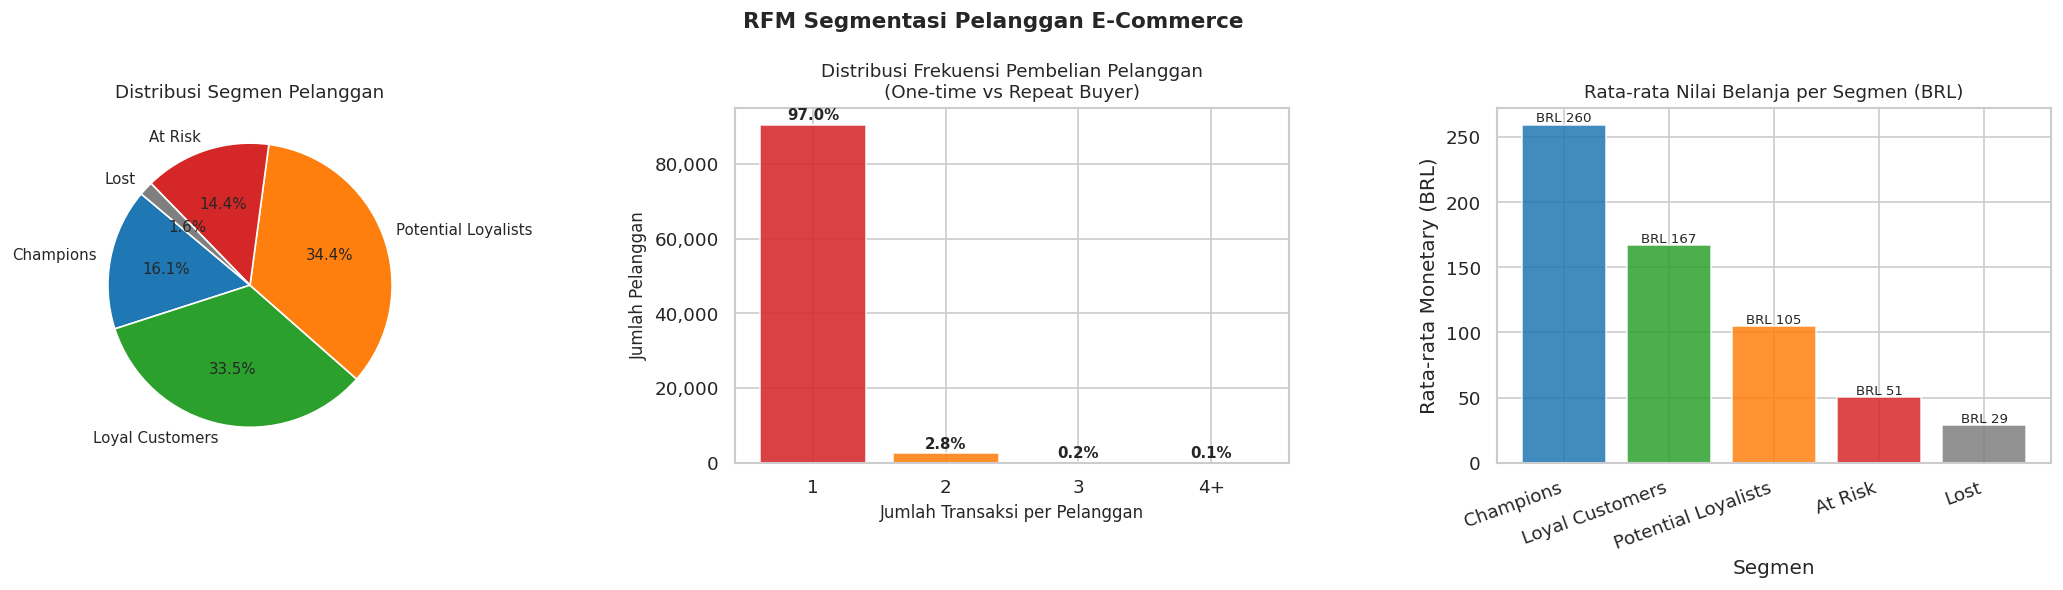

In [80]:
# Analisis Lanjutan: RFM Segmentasi Pelanggan

snapshot_date = pd.Timestamp('2018-10-18')

rfm = df_delivered.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('price', 'sum')
).reset_index()

# Scoring: 4 = terbaik, 1 = terburuk
# Gunakan .rank(method='first') pada semua kolom untuk menghindari error non-unique bin edges
# Konversi via float terlebih dahulu agar kompatibel dengan pandas versi baru
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'),   q=4, labels=[4, 3, 2, 1]).astype(float).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(float).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4]).astype(float).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segmentasi
def segment(row):
    if row['RFM_score'] >= 10:
        return 'Champions'
    elif row['RFM_score'] >= 8:
        return 'Loyal Customers'
    elif row['RFM_score'] >= 6:
        return 'Potential Loyalists'
    elif row['RFM_score'] >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    Jumlah_Pelanggan = ('customer_unique_id', 'count'),
    Avg_Recency      = ('Recency', 'mean'),
    Avg_Frequency    = ('Frequency', 'mean'),
    Avg_Monetary     = ('Monetary', 'mean')
).round(2)
print('=== RFM Segmentasi Pelanggan ===')
print(seg_summary.to_string())

# Hitung distribusi frekuensi pembelian
freq_dist = rfm['Frequency'].value_counts().sort_index()
one_time_pct = (rfm['Frequency'] == 1).sum() / len(rfm) * 100
repeat_pct   = 100 - one_time_pct
print(f'\nPelanggan 1x beli : {one_time_pct:.1f}%')
print(f'Repeat buyer      : {repeat_pct:.1f}%')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Segmentasi Pelanggan E-Commerce', fontsize=13, fontweight='bold')

seg_order  = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
seg_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#7f7f7f']

counts = rfm['Segment'].value_counts().reindex(seg_order, fill_value=0)
mask           = counts > 0
filtered_counts = counts[mask]
filtered_labels = [s for s, m in zip(seg_order, mask) if m]
filtered_colors = [c for c, m in zip(seg_colors, mask) if m]

# Plot 1: Pie chart distribusi segmen
axes[0].pie(filtered_counts, labels=filtered_labels, colors=filtered_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
axes[0].set_title('Distribusi Segmen Pelanggan', fontsize=11)

# Plot 2: Bar chart frekuensi pembelian (memvisualisasikan dominasi one-time buyer)
ax2 = axes[1]
# Kelompokkan: 1x, 2x, 3x, 4x+
freq_groups = rfm['Frequency'].apply(lambda x: str(x) if x <= 3 else '4+')
freq_cnt    = freq_groups.value_counts().reindex(['1', '2', '3', '4+'], fill_value=0)
bar_colors  = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax2.bar(freq_cnt.index, freq_cnt.values, color=bar_colors, alpha=0.88, edgecolor='white')
total = len(rfm)
for bar, val in zip(bars, freq_cnt.values):
    pct = val / total * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Distribusi Frekuensi Pembelian Pelanggan\n(One-time vs Repeat Buyer)', fontsize=11)
ax2.set_xlabel('Jumlah Transaksi per Pelanggan', fontsize=10)
ax2.set_ylabel('Jumlah Pelanggan', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# Plot 3: Bar chart rata-rata monetary per segmen
ax3 = axes[2]
avg_mon = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_order, fill_value=0)
bars3 = ax3.bar(seg_order, avg_mon, color=seg_colors, alpha=0.85)
ax3.set_title('Rata-rata Nilai Belanja per Segmen (BRL)', fontsize=11)
ax3.set_xlabel('Segmen')
ax3.set_ylabel('Rata-rata Monetary (BRL)')
ax3.set_xticklabels(seg_order, rotation=20, ha='right')
for bar, val in zip(bars3, avg_mon):
    if val > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, val + 2,
                 f'BRL {val:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


**Insight RFM:**
- Bar chart distribusi frekuensi pembelian memperlihatkan bahwa mayoritas pelanggan (sekitar 96–97%) hanya melakukan **1 kali transaksi**, sementara repeat buyer (2x atau lebih) sangat sedikit. Ini menunjukkan tantangan besar dalam hal **customer retention** pada platform ini.
- Segmen **Champions** adalah pelanggan yang berbelanja baru-baru ini, sering, dan dengan nilai tinggi, meski jumlahnya kecil mereka berkontribusi besar pada pendapatan.
- Segmen **At Risk** dan **Lost** perlu menjadi prioritas program re-engagement seperti email marketing, voucher eksklusif, atau program loyalitas untuk mendorong repeat purchase.


## Simpan dan Export Data


In [81]:
# Export main_data.csv

# Gabungkan df_delivered dengan informasi reviews
order_review_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()
order_review_agg.rename(columns={'review_score': 'avg_review_score'}, inplace=True)

main_data = df_delivered[[
    'order_id',
    'customer_id',
    'product_id',
    'product_category_name_english',
    'price',
    'freight_value',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'year',
    'month',
    'year_month',
    'delay_days',
    'is_late',
    'customer_state',
    'customer_city',
]].copy()

# Gabungkan dengan review score
main_data = main_data.merge(order_review_agg, on='order_id', how='left')

# Konversi year_month ke string agar bisa disimpan ke CSV
main_data['year_month'] = main_data['year_month'].astype(str)

# Simpan ke CSV
main_data.to_csv('main_data.csv', index=False)

print(f'main_data.csv berhasil disimpan!')
print(f'Shape: {main_data.shape}')
print(f'\nKolom yang tersimpan:')
for col in main_data.columns:
    print(f'  - {col}')
print(f'\nSample data:')
main_data.head()


main_data.csv berhasil disimpan!
Shape: (110197, 18)

Kolom yang tersimpan:
  - order_id
  - customer_id
  - product_id
  - product_category_name_english
  - price
  - freight_value
  - order_status
  - order_purchase_timestamp
  - order_delivered_customer_date
  - order_estimated_delivery_date
  - year
  - month
  - year_month
  - delay_days
  - is_late
  - customer_state
  - customer_city
  - avg_review_score

Sample data:


,order_id,customer_id,product_id,product_category_name_english,price,freight_value,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,year,month,year_month,delay_days,is_late,customer_state,customer_city,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,2017,9,2017-09,-9.00,False,RJ,campos dos goytacazes,5.00
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,2017,4,2017-04,-3.00,False,SP,santa fe do sul,4.00
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,199.00,17.87,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,2018,1,2018-01,-14.00,False,MG,para de minas,5.00
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,perfumery,12.99,12.79,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,2018,8,2018-08,-6.00,False,SP,atibaia,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,garden_tools,199.90,18.14,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,2017,2,2017-02,-16.00,False,SP,varzea paulista,5.00


In [82]:
# Verifikasi file CSV berhasil disimpan
import os

csv_path = 'main_data.csv'
if os.path.exists(csv_path):
    file_size = os.path.getsize(csv_path) / (1024 * 1024)  # MB
    df_check = pd.read_csv(csv_path, nrows=5)
    print(f'File: {csv_path}')
    print(f'Ukuran: {file_size:.2f} MB')
    print(f'Kolom: {list(df_check.columns)}')
    print(f'\nVerifikasi selesai — main_data.csv siap digunakan oleh dashboard Streamlit.')
else:
    print('ERROR: File tidak ditemukan!')


File: main_data.csv
Ukuran: 24.20 MB
Kolom: ['order_id', 'customer_id', 'product_id', 'product_category_name_english', 'price', 'freight_value', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'year_month', 'delay_days', 'is_late', 'customer_state', 'customer_city', 'avg_review_score']

Verifikasi selesai — main_data.csv siap digunakan oleh dashboard Streamlit.


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori **health_beauty** adalah kategori dengan revenue tertinggi di 2018 (BRL ~756K), mengalami pertumbuhan sebesar 59% dari 2017. Diikuti oleh **watches_gifts** dan **bed_bath_table**. Hampir semua top-8 kategori mengalami pertumbuhan positif dari 2017 ke 2018, mencerminkan ekspansi platform secara keseluruhan. Kategori-kategori ini adalah pilar pendapatan utama yang perlu dipertahankan dan ditingkatkan kapasitas stoknya.

- **Conclusion pertanyaan 2:** Keterlambatan pengiriman memiliki dampak yang sangat negatif dan terukur terhadap kepuasan pelanggan. Pesanan yang terlambat mendapat rata-rata review score 2.27 versus 4.29 untuk pesanan tepat waktu. Pola ini bersifat linear. Semakin parah keterlambatan, semakin rendah skor ulasan. Hal ini menegaskan bahwa logistik dan pemenuhan SLA pengiriman adalah faktor kritikal dalam menjaga reputasi platform.

**Rekomendasi Action Item:**

1. **Prioritaskan investasi pada kategori health_beauty dan watches_gifts** dengan meningkatkan ketersediaan stok, memperbanyak seller pada kategori tersebut, dan mengalokasikan lebih banyak budget promosi untuk kategori-kategori ini mengingat pertumbuhannya yang pesat.

2. **Perbaiki SLA pengiriman untuk menekan angka keterlambatan** dari 6.77% ke bawah 3%. Implementasikan sistem monitoring real-time untuk pesanan yang berisiko terlambat dan prioritaskan penanganannya. Pertimbangkan kerja sama dengan lebih banyak mitra logistik di area dengan tingkat keterlambatan tinggi.

3. **Terapkan strategi 'under-promise, over-deliver'** pada estimasi pengiriman: data menunjukkan bahwa pesanan yang sampai jauh lebih cepat dari estimasi mendapat skor ulasan tertinggi. Pertimbangkan untuk menambahkan buffer waktu pada estimasi pengiriman kepada pelanggan.

4. **Luncurkan program loyalitas berbasis RFM** untuk meningkatkan repeat purchase rate yang saat ini hanya sekitar 3%. Targetkan segmen 'At Risk' dengan voucher re-engagement dan segmen 'Champions' dengan program eksklusif untuk mempertahankan mereka.